In [3]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

hemantthegood_flowers_data_path = kagglehub.dataset_download('hemantthegood/flowers-data')
hemantthegood_flower_test_data_path = kagglehub.dataset_download('hemantthegood/flower-test-data')

print('Data source import complete.')


100%|██████████| 440M/440M [00:03<00:00, 116MB/s]

Extracting files...


100%|██████████| 67.6k/67.6k [00:00<00:00, 47.0MB/s]

Extracting files...
Data source import complete.


**In this notebook we will train model to classify flower in 14 categories and export it to onxx, to deploy.**

In [5]:
import os
import numpy as np # linear algebra
from fastcore.all import *
from fastai.vision.all import *
import time, json
from pathlib import Path

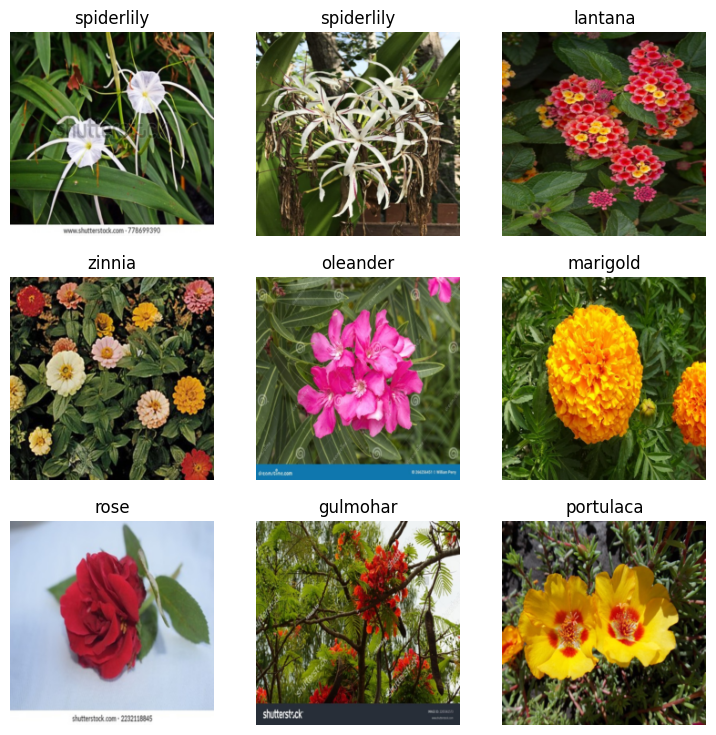

In [6]:
# Create Dataloader
path = hemantthegood_flowers_data_path
dls = ImageDataLoaders.from_folder(
    path,
    item_tfms=Resize(224),  # Resize images to 224x224
    valid_pct=0.2,
)
dls.show_batch()

**Train**

In [7]:
learn = vision_learner(dls, convnext_tiny, metrics=error_rate)
learn.fine_tune(3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 112MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.623372,0.889192,0.247780,01:00


epoch,train_loss,valid_loss,error_rate,time
0,0.995950,0.578804,0.166263,01:35
1,0.683048,0.457531,0.124294,01:39
2,0.465406,0.437773,0.121065,01:39


In [8]:
class_names = learn.dls.vocab
print(class_names)
import json
with open('class_names.json', 'w') as f:
    json.dump(list(class_names), f)

['amaltas', 'ashokatree', 'bottlebrushtree', 'bougainvillea', 'butterflypea', 'chrysanthemum', 'cockscomb', 'cosmos', 'dahlia', 'gulmohar', 'hibiscus', 'ixora', 'jasmine', 'kachnar', 'lantana', 'lotus', 'marigold', 'mexicanpetunia', 'nightqueen', 'oleander', 'palash', 'periwinkle', 'petunia', 'plumeria', 'portulaca', 'prideofindia', 'rainlily', 'rangooncreeper', 'rose', 'silkcottontree', 'spiderlily', 'sunflower', 'trumpettree', 'tuberose', 'zinnia']


**Test**

In [9]:
import torch
scripted_model = torch.jit.script(learn.model)
scripted_model.save("/content/flower-classification_convnext.pt")